# Churn Prediction Model
## Part 3 — D2C Customer Churn Intelligence

**Objective:** Build, evaluate, and document a churn prediction model that identifies customers likely to churn in the next 60 days.

**Leakage Rule:** Use ONLY features available on or before `2025-09-30` (snapshot date). The target window is `2025-10-01` to `2025-11-29`.

---

## 0. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

# Sklearn — data prep
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Sklearn — models
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Sklearn — evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
os.makedirs('charts', exist_ok=True)

# Fixed seed for reproducibility — same results every run
SEED = 42

print('Setup complete.')

Setup complete.


---
## 1. Data Loading & Leakage Check

We use `rfm_modeling_snapshot.csv` as our primary feature table.
Per the data dictionary, **all features in this file are safe to use** — computed as of snapshot date `2025-09-30` with no post-snapshot leakage.

In [2]:
DATA_DIR = 'data/'

# Load primary modeling table
# rfm_modeling_snapshot is pre-built with leakage-free features
df = pd.read_csv(DATA_DIR + 'rfm_modeling_snapshot.csv')

print(f'Dataset shape: {df.shape}')
print(f'\nColumns:')
print(df.columns.tolist())
print(f'\nTarget distribution:')
print(df['churn_next_60d'].value_counts())
print(f'\nChurn rate: {df["churn_next_60d"].mean():.2%}')
print(f'\nSplit distribution:')
print(df['split'].value_counts())
display(df.head(3))

Dataset shape: (2400, 29)

Columns:
['customer_id', 'snapshot_date', 'city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'marketing_consent', 'recency_days', 'frequency_180d', 'monetary_180d', 'return_rate_180d', 'avg_discount_pct_180d', 'avg_rating_180d', 'category_diversity_180d', 'ticket_count_90d', 'negative_ticket_rate_90d', 'avg_resolution_hours_90d', 'days_since_signup', 'sessions_30d', 'product_views_30d', 'cart_adds_30d', 'wishlist_adds_30d', 'abandoned_carts_30d', 'email_opens_30d', 'campaign_clicks_30d', 'last_visit_days_ago', 'churn_next_60d', 'split']

Target distribution:
churn_next_60d
0    1273
1    1127
Name: count, dtype: int64

Churn rate: 46.96%

Split distribution:
split
train         1728
validation     336
test           336
Name: count, dtype: int64


,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,monetary_180d,return_rate_180d,avg_discount_pct_180d,avg_rating_180d,category_diversity_180d,ticket_count_90d,negative_ticket_rate_90d,avg_resolution_hours_90d,days_since_signup,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split
0,CUST00001,2025-09-30,Tier 1,18-24,Instagram,Silver,Makeup,Yes,107,1,362.7300,0.0000,0.2300,3.0000,1,0,0.0000,0.0000,524,1,4,0,0,0,2,0,20,1,train
1,CUST00002,2025-09-30,Tier 2,25-34,Marketplace,Silver,Hair Care,Yes,40,1,581.0000,0.0000,0.2300,4.0000,1,1,0.0000,1.0000,121,8,31,4,2,3,0,0,0,0,train
2,CUST00003,2025-09-30,Tier 1,25-34,Influencer,NaN,Skin Care,Yes,171,1,649.9800,0.0000,0.4700,2.0000,1,0,0.0000,0.0000,206,1,3,0,0,0,0,0,26,1,train


In [3]:
# LEAKAGE CHECK — explicitly document which columns are excluded and why
# These columns must NEVER be used as model features

LEAKAGE_COLUMNS = [
    'churn_next_60d',  # This IS the target — never a feature
    'split',           # Train/val/test assignment — data management only
    'customer_id',     # Identifier — not a predictive feature
    'snapshot_date',   # Always 2025-09-30 — no predictive value
]

print('Columns excluded from features (leakage/non-predictive):')
for col in LEAKAGE_COLUMNS:
    print(f'  - {col}')


Columns excluded from features (leakage/non-predictive):
  - churn_next_60d
  - split
  - customer_id
  - snapshot_date


---
## 2. Feature Preparation

In [4]:
# Categorical features = text/label columns that need encoding
CATEGORICAL_FEATURES = [
    'city_tier',
    'age_group',
    'acquisition_channel',
    'loyalty_tier',
    'preferred_category',
    'marketing_consent',
]

# Numerical features = numbers that can be used directly
NUMERICAL_FEATURES = [
    'recency_days',
    'frequency_180d',
    'monetary_180d',
    'return_rate_180d',
    'avg_discount_pct_180d',
    'avg_rating_180d',
    'category_diversity_180d',
    'ticket_count_90d',
    'negative_ticket_rate_90d',
    'avg_resolution_hours_90d',
    'days_since_signup',
    'sessions_30d',
    'product_views_30d',
    'cart_adds_30d',
    'wishlist_adds_30d',
    'abandoned_carts_30d',
    'email_opens_30d',
    'campaign_clicks_30d',
    'last_visit_days_ago',
]

ALL_FEATURES = CATEGORICAL_FEATURES + NUMERICAL_FEATURES
TARGET = 'churn_next_60d'

print(f'Total features: {len(ALL_FEATURES)}')
print(f'Categorical: {len(CATEGORICAL_FEATURES)}')
print(f'Numerical: {len(NUMERICAL_FEATURES)}')
print(f'\nMissing values in features:')
missing = df[ALL_FEATURES].isnull().sum()
print(missing[missing > 0])

Total features: 25
Categorical: 6
Numerical: 19

Missing values in features:
loyalty_tier    1386
dtype: int64


In [5]:
# Handle missing values
df_model = df.copy()

# loyalty_tier nulls = not enrolled in loyalty programme
df_model['loyalty_tier'] = df_model['loyalty_tier'].fillna('Not Enrolled')

# Fill remaining categoricals with Unknown
for col in CATEGORICAL_FEATURES:
    df_model[col] = df_model[col].fillna('Unknown')

# Fill numerical nulls with median
# Median is more robust than mean for skewed distributions
for col in NUMERICAL_FEATURES:
    df_model[col] = df_model[col].fillna(df_model[col].median())

# Label encode categorical features
# Converts text categories to numbers e.g. Tier1=0, Tier2=1, Tier3=2
label_encoders = {}
for col in CATEGORICAL_FEATURES:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    label_encoders[col] = le

print('Missing values after treatment:', df_model[ALL_FEATURES].isnull().sum().sum())
print('All features ready for modeling.')
df_model


Missing values after treatment: 0
All features ready for modeling.


,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,monetary_180d,return_rate_180d,avg_discount_pct_180d,avg_rating_180d,category_diversity_180d,ticket_count_90d,negative_ticket_rate_90d,avg_resolution_hours_90d,days_since_signup,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split
0,CUST00001,2025-09-30,0,0,2,3,3,1,107,1,362.7300,0.0000,0.2300,3.0000,1,0,0.0000,0.0000,524,1,4,0,0,0,2,0,20,1,train
1,CUST00002,2025-09-30,1,1,3,3,2,1,40,1,581.0000,0.0000,0.2300,4.0000,1,1,0.0000,1.0000,121,8,31,4,2,3,0,0,0,0,train
2,CUST00003,2025-09-30,0,1,1,1,4,1,171,1,649.9800,0.0000,0.4700,2.0000,1,0,0.0000,0.0000,206,1,3,0,0,0,0,0,26,1,train
3,CUST00004,2025-09-30,2,1,0,1,1,0,131,1,1604.0400,0.0000,0.1600,2.0000,1,0,0.0000,0.0000,168,1,6,0,0,0,0,0,14,1,train
4,CUST00005,2025-09-30,2,2,4,0,2,1,38,3,1781.9000,0.0000,0.4800,1.0000,2,0,0.0000,0.0000,405,18,95,4,1,1,3,1,9,0,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2395,CUST02396,2025-09-30,1,2,2,1,0,0,114,1,553.8800,0.0000,0.2300,5.0000,1,0,0.0000,0.0000,210,1,3,0,0,0,0,0,42,1,train
2396,CUST02397,2025-09-30,0,1,3,3,1,1,58,1,451.6800,0.0000,0.3400,4.0000,1,0,0.0000,0.0000,75,12,59,3,1,2,3,1,25,0,train
2397,CUST02398,2025-09-30,1,3,0,1,2,1,49,2,1168.2600,0.0000,0.2950,4.0000,2,0,0.0000,0.0000,464,4,17,1,0,1,0,0,10,0,train
2398,CUST02399,2025-09-30,0,3,2,1,5,1,276,0,0.0000,0.0000,0.0000,3.5000,0,0,0.0000,0.0000,428,1,4,1,0,1,5,1,60,1,validation


---
## 3. Train / Validation / Test Split

We use the **pre-assigned `split` column** from the data dictionary.
This ensures consistent evaluation across all submissions.

In [6]:
# Use pre-assigned splits — do NOT re-split randomly
train_df = df_model[df_model['split'] == 'train']
val_df   = df_model[df_model['split'] == 'validation']
test_df  = df_model[df_model['split'] == 'test']

# X = features, y = target
X_train = train_df[ALL_FEATURES]
y_train = train_df[TARGET]
X_val   = val_df[ALL_FEATURES]
y_val   = val_df[TARGET]
X_test  = test_df[ALL_FEATURES]
y_test  = test_df[TARGET]

print('=== Split Sizes ===')
print(f'Train      : {X_train.shape[0]} rows | Churn rate: {y_train.mean():.2%}')
print(f'Validation : {X_val.shape[0]} rows | Churn rate: {y_val.mean():.2%}')
print(f'Test       : {X_test.shape[0]} rows | Churn rate: {y_test.mean():.2%}')

=== Split Sizes ===
Train      : 1728 rows | Churn rate: 46.99%
Validation : 336 rows | Churn rate: 43.75%
Test       : 336 rows | Churn rate: 50.00%


---
## 4. Baseline Model — Logistic Regression

Simple, interpretable baseline. Gives us a performance floor to beat with XGBoost.

In [7]:
# Pipeline chains scaler + model together
# Ensures scaler is fit ONLY on train data — prevents leakage through scaling
baseline_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        random_state=SEED,
        max_iter=1000,
        class_weight='balanced'  # handles class imbalance automatically
    ))
])

baseline_pipeline.fit(X_train, y_train)

# predict_proba returns probabilities — we take [:, 1] for churn probability
baseline_val_probs = baseline_pipeline.predict_proba(X_val)[:, 1]
baseline_val_preds = baseline_pipeline.predict(X_val)

print('=== Baseline (Logistic Regression) — Validation ===')
print(f'Accuracy  : {accuracy_score(y_val, baseline_val_preds):.4f}')
print(f'Precision : {precision_score(y_val, baseline_val_preds):.4f}')
print(f'Recall    : {recall_score(y_val, baseline_val_preds):.4f}')
print(f'F1 Score  : {f1_score(y_val, baseline_val_preds):.4f}')
print(f'ROC-AUC   : {roc_auc_score(y_val, baseline_val_probs):.4f}')
print(f'PR-AUC    : {average_precision_score(y_val, baseline_val_probs):.4f}')
print(f'\nConfusion Matrix:')
print(confusion_matrix(y_val, baseline_val_preds))

=== Baseline (Logistic Regression) — Validation ===
Accuracy  : 0.8244
Precision : 0.8143
Recall    : 0.7755
F1 Score  : 0.7944
ROC-AUC   : 0.8849
PR-AUC    : 0.8696

Confusion Matrix:
[[163  26]
 [ 33 114]]


---
## 5. Stronger Model — XGBoost

Gradient boosting — builds trees sequentially where each tree corrects errors of the previous. Typically outperforms Logistic Regression on tabular data.

In [8]:
# scale_pos_weight handles class imbalance
# = count(non-churners) / count(churners)
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f'Non-churn: {neg_count} | Churn: {pos_count} | scale_pos_weight: {scale_pos_weight:.2f}')

xgb_model = XGBClassifier(
    n_estimators=500,         # number of trees
    max_depth=3,              # max depth of each tree
    learning_rate=0.01,       # contribution of each tree
    subsample=0.7,            # fraction of rows per tree
    colsample_bytree=0.7,     # fraction of features per tree
    scale_pos_weight=scale_pos_weight,
    random_state=SEED,
    eval_metric='logloss',
    early_stopping_rounds=50, # stop if no improvement for 30 rounds
    verbosity=0
)

# Train with early stopping on validation set
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print(f'Best iteration: {xgb_model.best_iteration}')

xgb_val_probs = xgb_model.predict_proba(X_val)[:, 1]
xgb_val_preds = xgb_model.predict(X_val)

print('\n=== XGBoost — Validation ===')
print(f'Accuracy  : {accuracy_score(y_val, xgb_val_preds):.4f}')
print(f'Precision : {precision_score(y_val, xgb_val_preds):.4f}')
print(f'Recall    : {recall_score(y_val, xgb_val_preds):.4f}')
print(f'F1 Score  : {f1_score(y_val, xgb_val_preds):.4f}')
print(f'ROC-AUC   : {roc_auc_score(y_val, xgb_val_probs):.4f}')
print(f'PR-AUC    : {average_precision_score(y_val, xgb_val_probs):.4f}')
print(f'\nConfusion Matrix:')
print(confusion_matrix(y_val, xgb_val_preds))

Non-churn: 916 | Churn: 812 | scale_pos_weight: 1.13
Best iteration: 499

=== XGBoost — Validation ===
Accuracy  : 0.7976
Precision : 0.7687
Recall    : 0.7687
F1 Score  : 0.7687
ROC-AUC   : 0.8822
PR-AUC    : 0.8678

Confusion Matrix:
[[155  34]
 [ 34 113]]


In [9]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=500,        # number of trees
    max_depth=10,            # max depth of each tree
    min_samples_leaf=5,      # minimum samples at leaf node
    max_features='sqrt',     # features considered per split
    class_weight='balanced', # handles class imbalance
    random_state=SEED,
    n_jobs=-1                # use all CPU cores
)

rf_model.fit(X_train, y_train)

rf_val_probs = rf_model.predict_proba(X_val)[:, 1]
rf_val_preds = rf_model.predict(X_val)

print('=== Random Forest — Validation ===')
print(f'Accuracy  : {accuracy_score(y_val, rf_val_preds):.4f}')
print(f'Precision : {precision_score(y_val, rf_val_preds):.4f}')
print(f'Recall    : {recall_score(y_val, rf_val_preds):.4f}')
print(f'F1 Score  : {f1_score(y_val, rf_val_preds):.4f}')
print(f'ROC-AUC   : {roc_auc_score(y_val, rf_val_probs):.4f}')
print(f'PR-AUC    : {average_precision_score(y_val, rf_val_probs):.4f}')
print(f'\nConfusion Matrix:')
print(confusion_matrix(y_val, rf_val_preds))

=== Random Forest — Validation ===
Accuracy  : 0.8006
Precision : 0.7899
Recall    : 0.7415
F1 Score  : 0.7649
ROC-AUC   : 0.8793
PR-AUC    : 0.8527

Confusion Matrix:
[[160  29]
 [ 38 109]]


---
## 6. Model Comparison Charts

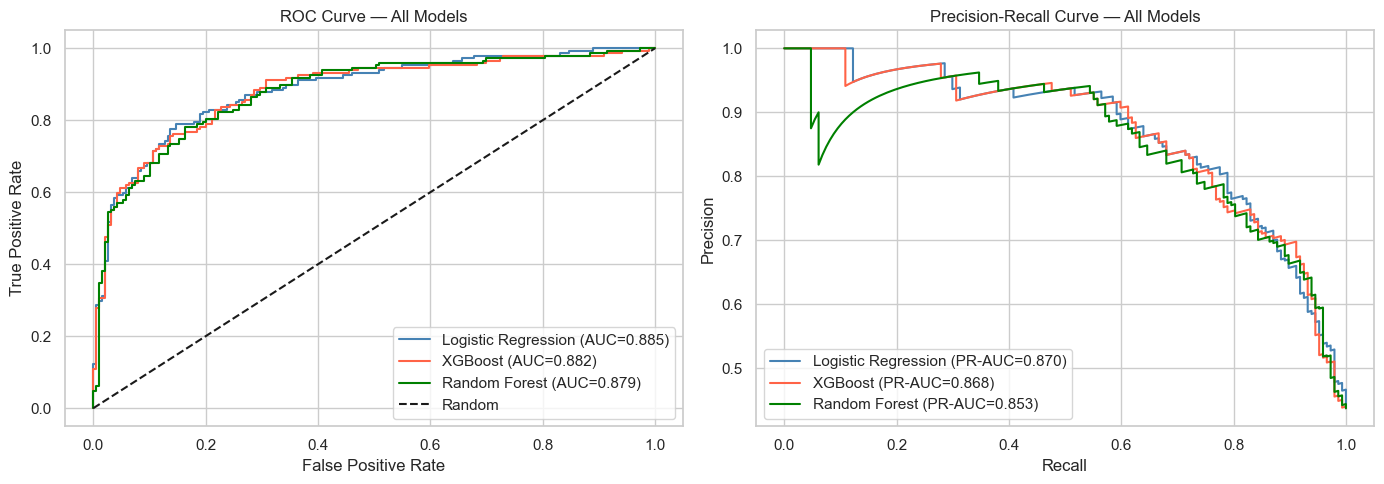

In [17]:
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, average_precision_score

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Define model list separately — avoids syntax confusion
model_names  = ['Logistic Regression', 'XGBoost', 'Random Forest']
model_probs  = [baseline_val_probs, xgb_val_probs, rf_val_probs]
model_colors = ['steelblue', 'tomato', 'green']

# ROC curves
for i in range(len(model_names)):
    fpr, tpr, _ = roc_curve(y_val, model_probs[i])
    auc = roc_auc_score(y_val, model_probs[i])
    axes[0].plot(fpr, tpr, 
                 label=f'{model_names[i]} (AUC={auc:.3f})', 
                 color=model_colors[i])

axes[0].plot([0,1], [0,1], 'k--', label='Random')
axes[0].set_title('ROC Curve — All Models')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# PR curves
for i in range(len(model_names)):
    prec, rec, _ = precision_recall_curve(y_val, model_probs[i])
    pr_auc = average_precision_score(y_val, model_probs[i])
    axes[1].plot(rec, prec,
                 label=f'{model_names[i]} (PR-AUC={pr_auc:.3f})',
                 color=model_colors[i])

axes[1].set_title('Precision-Recall Curve — All Models')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

plt.tight_layout()
plt.savefig('charts/chart1_model_comparison.png', dpi=150)
plt.show()

---
## 7. Threshold Selection

**Business context:**
- False Negative (missed churner) = customer leaves without intervention = HIGH cost
- False Positive (wrong prediction) = wasted retention offer = LOW cost

We prefer higher Recall (catch more churners) and select threshold that maximises F1 while keeping Recall >= 0.70.

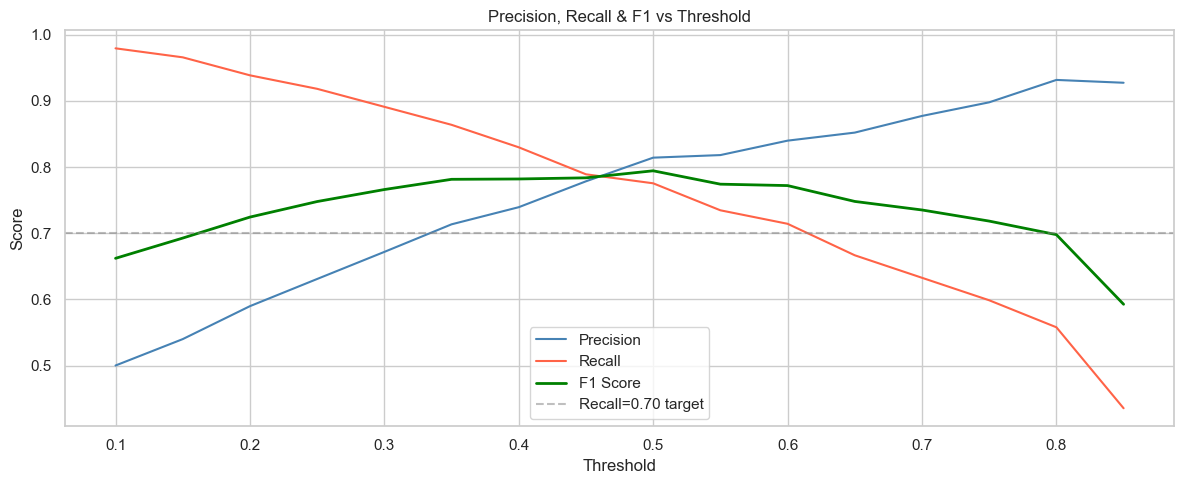

Selected threshold : 0.5
Precision          : 0.8143
Recall             : 0.7755
F1 Score           : 0.7944


,threshold,precision,recall,f1
0,0.1000,0.5000,0.9796,0.6621
1,0.1500,0.5399,0.9660,0.6927
2,0.2000,0.5897,0.9388,0.7244
3,0.2500,0.6308,0.9184,0.7479
4,0.3000,0.6718,0.8912,0.7661
5,0.3500,0.7135,0.8639,0.7815
6,0.4000,0.7394,0.8299,0.7821
7,0.4500,0.7785,0.7891,0.7838
8,0.5000,0.8143,0.7755,0.7944
9,0.5500,0.8182,0.7347,0.7742


In [19]:
# Test different thresholds on validation set
thresholds = np.arange(0.1, 0.9, 0.05)
results = []

for thresh in thresholds:
    preds = (baseline_val_probs >= thresh).astype(int)
    results.append({
        'threshold': round(thresh, 2),
        'precision': precision_score(y_val, preds, zero_division=0),
        'recall':    recall_score(y_val, preds, zero_division=0),
        'f1':        f1_score(y_val, preds, zero_division=0),
    })

thresh_df = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(thresh_df['threshold'], thresh_df['precision'], label='Precision', color='steelblue')
ax.plot(thresh_df['threshold'], thresh_df['recall'],    label='Recall',    color='tomato')
ax.plot(thresh_df['threshold'], thresh_df['f1'],        label='F1 Score',  color='green', linewidth=2)
ax.axhline(y=0.70, color='gray', linestyle='--', alpha=0.5, label='Recall=0.70 target')
ax.set_title('Precision, Recall & F1 vs Threshold')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.legend()
plt.tight_layout()
plt.savefig('charts/chart2_threshold_analysis.png', dpi=150)
plt.show()

# Select best threshold — maximise F1 with recall >= 0.70
best_row = thresh_df[thresh_df['recall'] >= 0.70].sort_values('f1', ascending=False).iloc[0]
BEST_THRESHOLD = best_row['threshold']

print(f'Selected threshold : {BEST_THRESHOLD}')
print(f'Precision          : {best_row["precision"]:.4f}')
print(f'Recall             : {best_row["recall"]:.4f}')
print(f'F1 Score           : {best_row["f1"]:.4f}')
display(thresh_df)

---
## 8. Final Evaluation on Test Set

Test set is touched ONLY once — at the very end.

=== FINAL MODEL — Test Set Results ===
Threshold  : 0.5
Accuracy   : 0.8065
Precision  : 0.8047
Recall     : 0.8095
F1 Score   : 0.8071
ROC-AUC    : 0.8856
PR-AUC     : 0.8778

TP: 136 | FP: 33 | TN: 135 | FN: 32


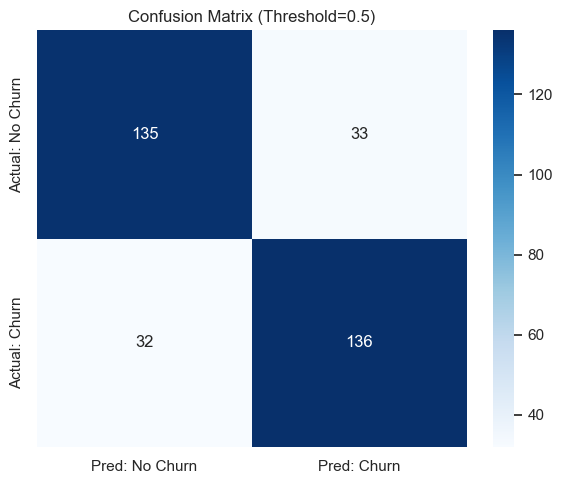

In [22]:
# Final evaluation on held-out test set
baseline_test_probs = baseline_pipeline.predict_proba(X_test)[:, 1]
baseline_test_preds = (baseline_test_probs >= BEST_THRESHOLD).astype(int)

test_accuracy  = accuracy_score(y_test, baseline_test_preds)
test_precision = precision_score(y_test, baseline_test_preds)
test_recall    = recall_score(y_test, baseline_test_preds)
test_f1        = f1_score(y_test, baseline_test_preds)
test_roc_auc   = roc_auc_score(y_test, baseline_test_probs)
test_pr_auc    = average_precision_score(y_test, baseline_test_probs)
cm             = confusion_matrix(y_test, baseline_test_preds)
tn, fp, fn, tp = cm.ravel()

print('=== FINAL MODEL — Test Set Results ===')
print(f'Threshold  : {BEST_THRESHOLD}')
print(f'Accuracy   : {test_accuracy:.4f}')
print(f'Precision  : {test_precision:.4f}')
print(f'Recall     : {test_recall:.4f}')
print(f'F1 Score   : {test_f1:.4f}')
print(f'ROC-AUC    : {test_roc_auc:.4f}')
print(f'PR-AUC     : {test_pr_auc:.4f}')
print(f'\nTP: {tp} | FP: {fp} | TN: {tn} | FN: {fn}')

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: No Churn', 'Pred: Churn'],
            yticklabels=['Actual: No Churn', 'Actual: Churn'])
ax.set_title(f'Confusion Matrix (Threshold={BEST_THRESHOLD})')
plt.tight_layout()
plt.savefig('charts/chart3_confusion_matrix.png', dpi=150)
plt.show()

---
## 9. Feature Importance

Top 15 Most Important Features (Logistic Regression):


,feature,coefficient,importance
6,recency_days,1.7384,1.7384
8,monetary_180d,-0.4483,0.4483
9,return_rate_180d,0.3446,0.3446
13,ticket_count_90d,-0.3108,0.3108
14,negative_ticket_rate_90d,0.3047,0.3047
24,last_visit_days_ago,0.2744,0.2744
10,avg_discount_pct_180d,0.2711,0.2711
17,sessions_30d,-0.1993,0.1993
23,campaign_clicks_30d,-0.1673,0.1673
7,frequency_180d,-0.1623,0.1623


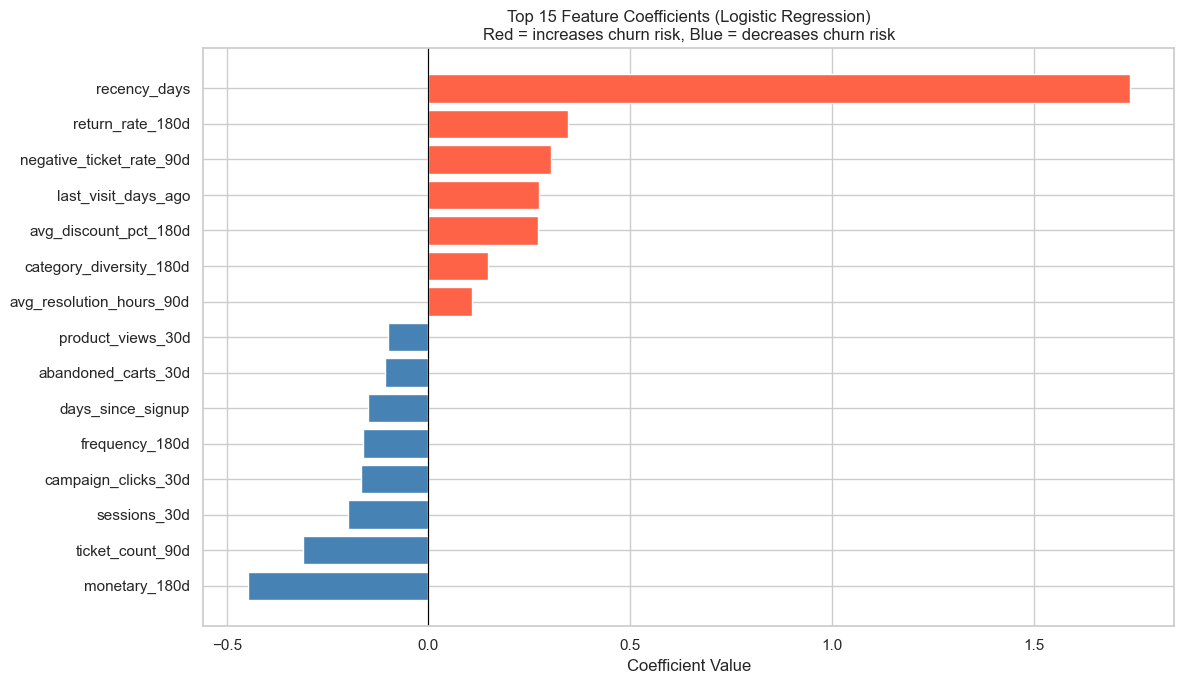

In [25]:
# Feature importance for Logistic Regression
# LR uses coefficients — positive = increases churn risk, negative = decreases
lr_model = baseline_pipeline.named_steps['model']
lr_scaler = baseline_pipeline.named_steps['scaler']

# Get absolute coefficient values — higher absolute value = more important
coefficients = lr_model.coef_[0]  # coef_ is 2D array, take first row

feat_importance = pd.DataFrame({
    'feature':     ALL_FEATURES,
    'coefficient': coefficients,
    'importance':  abs(coefficients)  # absolute value for ranking
}).sort_values('importance', ascending=False)

print('Top 15 Most Important Features (Logistic Regression):')
display(feat_importance.head(15))

# Plot top 15 — use actual coefficients to show direction
fig, ax = plt.subplots(figsize=(12, 7))
top15 = feat_importance.head(15).sort_values('coefficient')
colors = ['tomato' if c > 0 else 'steelblue' for c in top15['coefficient']]
ax.barh(top15['feature'], top15['coefficient'], color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Top 15 Feature Coefficients (Logistic Regression)\nRed = increases churn risk, Blue = decreases churn risk')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('charts/chart4_feature_importance.png', dpi=150)
plt.show()

---
## 10. Error Analysis

Identifying False Positives and False Negatives with specific customer examples.

In [27]:
# Build error analysis dataframe
error_df = test_df[['customer_id'] + ALL_FEATURES].copy()
error_df['predicted_proba'] = baseline_test_probs
error_df['predicted_label'] = baseline_test_preds
error_df['actual_label']    = y_test.values

# Classify each prediction
def classify_pred(row):
    if row['predicted_label'] == 1 and row['actual_label'] == 1:
        return 'TP'
    elif row['predicted_label'] == 1 and row['actual_label'] == 0:
        return 'FP'
    elif row['predicted_label'] == 0 and row['actual_label'] == 0:
        return 'TN'
    else:
        return 'FN'

error_df['pred_type'] = error_df.apply(classify_pred, axis=1)
print('Prediction type counts:')
print(error_df['pred_type'].value_counts())

# Top 10 False Positives — highest confidence wrong churn predictions
fp_df = error_df[error_df['pred_type'] == 'FP'].sort_values(
    'predicted_proba', ascending=False).head(10)

# Top 10 False Negatives — missed churners model was most confident about
fn_df = error_df[error_df['pred_type'] == 'FN'].sort_values(
    'predicted_proba', ascending=True).head(10)

key_cols = ['customer_id', 'predicted_proba', 'recency_days',
            'frequency_180d', 'monetary_180d', 'ticket_count_90d',
            'sessions_30d', 'return_rate_180d', 'last_visit_days_ago']

print('\n=== Top 10 False Positives (predicted churn, actually stayed) ===')
display(fp_df[key_cols].reset_index(drop=True))

print('\n=== Top 10 False Negatives (missed churners) ===')
display(fn_df[key_cols].reset_index(drop=True))

Prediction type counts:
pred_type
TP    136
TN    135
FP     33
FN     32
Name: count, dtype: int64

=== Top 10 False Positives (predicted churn, actually stayed) ===


,customer_id,predicted_proba,recency_days,frequency_180d,monetary_180d,ticket_count_90d,sessions_30d,return_rate_180d,last_visit_days_ago
0,CUST01246,0.9892,262,0,0.0000,0,1,0.0000,60
1,CUST01411,0.9583,183,0,0.0000,0,0,0.0000,51
2,CUST01325,0.9453,186,0,0.0000,0,1,0.0000,43
3,CUST01370,0.9138,161,2,1246.0400,0,2,0.0000,35
4,CUST00437,0.9061,151,1,729.2200,0,0,0.0000,33
5,CUST01017,0.8856,133,2,1167.2800,0,3,0.5000,13
6,CUST01405,0.8670,140,1,1013.0300,0,2,0.0000,20
7,CUST00491,0.8442,97,1,540.8900,1,10,1.0000,20
8,CUST01614,0.7921,103,2,1352.1100,0,4,0.5000,4
9,CUST01906,0.7817,81,1,555.3700,0,3,0.0000,28



=== Top 10 False Negatives (missed churners) ===


,customer_id,predicted_proba,recency_days,frequency_180d,monetary_180d,ticket_count_90d,sessions_30d,return_rate_180d,last_visit_days_ago
0,CUST02072,0.0581,35,7,4340.1900,0,4,0.0000,1
1,CUST01990,0.0884,59,4,3877.7700,0,11,0.0000,7
2,CUST00184,0.1028,14,3,2456.9100,0,6,0.0000,6
3,CUST00866,0.1378,26,1,1280.7100,0,5,0.0000,1
4,CUST01655,0.1436,13,2,1358.9900,0,2,0.0000,7
5,CUST01303,0.1471,20,1,844.7400,1,3,0.0000,0
6,CUST00592,0.2583,20,1,627.3600,0,3,0.0000,1
7,CUST02103,0.2920,44,2,1052.3100,1,0,0.0000,0
8,CUST02060,0.2948,23,2,1331.0100,2,4,0.5000,6
9,CUST00838,0.2955,9,1,402.6700,1,11,0.0000,12


---
## 11. Save Model & Metrics

In [28]:
# Side by side comparison table
# Save trained XGBoost model
# pickle serializes Python objects to binary — allows reloading without retraining
with open('model.pkl', 'wb') as f:
    pickle.dump(baseline_pipeline, f)
print('model.pkl saved.')

# Save label encoders — needed to preprocess new data the same way
with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)
print('label_encoders.pkl saved.')

# Save metrics as JSON
metrics = {
    'model': 'Logistic Regression',
    'threshold': float(BEST_THRESHOLD),
    'dataset': 'rfm_modeling_snapshot.csv',
    'split': 'pre-assigned (train/validation/test)',
    'test_metrics': {
        'accuracy':  round(test_accuracy, 4),
        'precision': round(test_precision, 4),
        'recall':    round(test_recall, 4),
        'f1_score':  round(test_f1, 4),
        'roc_auc':   round(test_roc_auc, 4),
        'pr_auc':    round(test_pr_auc, 4),
    },
    'confusion_matrix': {
        'TP': int(tp), 'FP': int(fp),
        'TN': int(tn), 'FN': int(fn)
    },
    'baseline_val_metrics': {
        'model':     'Logistic Regression',
        'accuracy':  round(accuracy_score(y_val, baseline_val_preds), 4),
        'precision': round(precision_score(y_val, baseline_val_preds), 4),
        'recall':    round(recall_score(y_val, baseline_val_preds), 4),
        'f1_score':  round(f1_score(y_val, baseline_val_preds), 4),
        'roc_auc':   round(roc_auc_score(y_val, baseline_val_probs), 4),
    },
    'top_10_features': feat_importance.head(10)['feature'].tolist(),
    'leakage_prevention': 'Used only rfm_modeling_snapshot.csv. Excluded: churn_next_60d, split, customer_id, snapshot_date.'
}

with open('metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print('metrics.json saved.')
print('\nFinal test metrics:')
print(json.dumps(metrics['test_metrics'], indent=2))

model.pkl saved.
label_encoders.pkl saved.
metrics.json saved.

Final test metrics:
{
  "accuracy": 0.8065,
  "precision": 0.8047,
  "recall": 0.8095,
  "f1_score": 0.8071,
  "roc_auc": 0.8856,
  "pr_auc": 0.8778
}
